# Executive Summary

I built a regression model to predict house prices using the Ames Housing dataset, focusing on how house quality, size, and condition interact to influence pricing.

One pattern became obvious very early during exploration: size alone was not enough to explain pricing differences. Larger houses were not always more expensive, but larger houses with higher construction quality consistently sold at disproportionately higher prices.

That observation led to the creation of this interaction feature:

QualityScore = OverallQual × GrLivArea

What surprised me later was that this feature did not just help slightly, it became the single strongest predictor in the entire project, contributing 47.24% feature importance in the Gradient Boosting model.

Five regression models were tested:
- Linear Regression
- Ridge
- Lasso
- Random Forest
- Gradient Boosting

Although Gradient Boosting and Lasso produced nearly identical performance, Lasso was selected as the final model because it matched Gradient Boosting on test accuracy while remaining simpler and easier to interpret.

# Final Model Performance

- R²: 0.91
- RMSE: $20,005

- MAE: $14,368

- MAPE: 8.8%

- 79% of predictions fall within $25K of actual sale price

Overall, the model captures most of the pricing variation while remaining stable and interpretable.

The biggest takeaway from this project was that interaction effects mattered more than I initially expected. Quality and size together explained pricing behavior far better than either feature alone.

# 1. Data Loading & Initial Exploration

Before starting preprocessing or modelling, I first wanted to understand how the dataset is structured and what kinds of variables dominate it.

At this stage, the goal is not prediction accuracy yet. The goal is to identify early patterns:
- whether price depends more on size, quality, or location
- whether missing values are random or meaningful
- whether the target variable already shows signs of skewness or outliers

These early observations directly influence later decisions like feature engineering, missing value treatment, and model selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import ( mean_squared_error, mean_absolute_error, r2_score )

import warnings
warnings.filterwarnings('ignore')

In [2]:
!gdown 18uQwyYD7xiV4OgWz7u4pt841_qaAD_Pu
!gdown 1DKyghHba5pAGHEHH_eszLXLPTwMmgxlL
!gdown 1FtrYd8yG9N9-1cJbsWiE8DSq6TOIMPVa

Downloading...
From: https://drive.google.com/uc?id=18uQwyYD7xiV4OgWz7u4pt841_qaAD_Pu
To: /content/train.csv
100% 461k/461k [00:00<00:00, 53.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DKyghHba5pAGHEHH_eszLXLPTwMmgxlL
To: /content/test.csv
100% 451k/451k [00:00<00:00, 69.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FtrYd8yG9N9-1cJbsWiE8DSq6TOIMPVa
To: /content/sample_submission.csv
100% 31.9k/31.9k [00:00<00:00, 6.49MB/s]


In [3]:
df_raw=pd.read_csv('train.csv')

In [4]:
df=df_raw.copy()

In [5]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.shape

(1460, 81)

In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns
print((f"Numerical: {len(num_cols)}, Categorical: {len(cat_cols)}"))

Numerical: 38, Categorical: 43


The dataset contains 1,460 records with 81 columns.

Out of these:
- 38 are numerical
- 43 are categorical

I expected the dataset to lean more heavily toward numerical variables because house pricing feels naturally tied to measurable things like size, age, and square footage. Instead, a surprisingly large portion of the dataset is categorical.

That immediately suggested that feature representation and encoding would matter a lot later.

One thing that stood out early was how many quality-related variables exist across different parts of the house:
- OverallQual
- ExterQual
- KitchenQual
- GarageQual
- BsmtQual

Quality is not measured in one place it appears throughout the entire property.

That raised an early hypothesis that house quality may influence pricing more consistently than any single size-related variable alone.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [11]:
print(f"Cheapest:       ${df["SalePrice"].min():>10,.0f}")
print(f"Median:         ${df["SalePrice"].median():>10,.0f}")
print(f"Mean:           ${df["SalePrice"].mean():>10,.0f}")
print(f"Most Expensive: ${df["SalePrice"].max():>10,.0f}")
print(f"skewness: {df["SalePrice"].skew():.2f}")

Cheapest:       $    34,900
Median:         $   163,000
Mean:           $   180,921
Most Expensive: $   755,000
skewness: 1.88


Even before plotting the target variable, the pricing distribution already looks uneven.

The median house price is $163K, while the mean is higher at $180K. That gap usually appears when a relatively small number of expensive houses pull the average upward.

The skewness value confirms it:
- Skewness = 1.88

That is high enough to expect modelling problems later if the target variable is left untransformed.

The price range is also unusually wide:
- cheapest house: $34,900
- most expensive house: $755,000

That spread makes outlier handling important, especially for regression models that are sensitive to extreme values.

Some feature ranges also look suspiciously large. LotArea, for example, reaches above 200,000 sqft, far beyond the typical property size in the dataset.

The missing values also do not look random.

Columns like PoolQC, Alley, and Fence have extremely high missing percentages, which usually means the feature itself is absent rather than unknown.

That distinction matters because treating these like ordinary missing values would create misleading information for the model.

In [12]:
missing=df.isnull().sum().sort_values(ascending=False)
missing_pct=(missing/len(df)*100).round(1)
missing_df=pd.DataFrame({'Count':missing,'%':missing_pct})
print(missing_df[missing_df['Count']>0])

              Count     %
PoolQC         1453  99.5
MiscFeature    1406  96.3
Alley          1369  93.8
Fence          1179  80.8
MasVnrType      872  59.7
FireplaceQu     690  47.3
LotFrontage     259  17.7
GarageQual       81   5.5
GarageFinish     81   5.5
GarageType       81   5.5
GarageYrBlt      81   5.5
GarageCond       81   5.5
BsmtFinType2     38   2.6
BsmtExposure     38   2.6
BsmtCond         37   2.5
BsmtQual         37   2.5
BsmtFinType1     37   2.5
MasVnrArea        8   0.5
Electrical        1   0.1


The missing value patterns here look intentional rather than random.

Several columns have extremely high missing percentages:
- PoolQC: 99.5%
- MiscFeature: 96.3%
- Alley: 93.8%
- Fence: 80.8%

At first glance, these look like low-quality columns that should simply be dropped.

But after checking the data description, the missing values actually carry meaning:
- missing PoolQC → no pool
- missing GarageType → no garage
- missing basement features → no basement

So these are not traditional missing values.

They are closer to “feature absence” indicators.

That changes the preprocessing strategy completely because filling these with averages or modes would incorrectly imply that the feature exists.

This became one of the most important preprocessing decisions in the project and heavily influenced how missing values were handled later.

# 2. Exploratory Data Analysis

After understanding the dataset structure and missing value patterns, the next step was to explore how different housing features relate to SalePrice.

The main goals of this section are to:
- identify the strongest drivers of house prices
- study the distribution of SalePrice
- detect skewness and extreme outliers
- examine relationships between numerical variables
- identify multicollinearity
- find patterns that could improve feature engineering later

The focus here is not just visualization.

I wanted to understand how buyers appear to value:
- quality
- size
- age
- location
- and overall house condition

before building any models.

In [13]:
numeric_df=df.select_dtypes(include=['int64','float64'])
correlation=numeric_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
print(correlation.head(15))

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


The first thing that stood out was how dominant OverallQual is.

It has a correlation of 0.79 with SalePrice, making it the single strongest original predictor in the dataset.

I initially expected Neighborhood-related features to dominate because real estate is usually associated with location. But the data shows that construction quality has an even stronger relationship with price than location alone.

The next strongest features also follow a very clear pattern:
- GrLivArea (0.71)
- GarageCars (0.64)
- GarageArea (0.62)
- TotalBsmtSF (0.61)
- 1stFlrSF (0.61)

Most of the strongest predictors are either:
- quality-related
- size-related
- or both together

That pattern started appearing repeatedly throughout the EDA and later became one of the main reasons for creating the QualityScore interaction feature.

Another thing I noticed was how strongly related some variables are to each other.

For example:
- GarageCars and GarageArea both appear near the top
- multiple square-footage features rank highly together

That usually signals multicollinearity, which later became important while choosing between ordinary linear regression and regularized models like Ridge and Lasso.

In [14]:
for i in sorted(df['OverallQual'].unique()):
  med=df[df['OverallQual']==i]['SalePrice'].median()
  print(f"Quality {i:2d}: ${med:>10,.0f}")

nb=df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
print(nb.head())
print(nb.tail())

Quality  1: $    50,150
Quality  2: $    60,000
Quality  3: $    86,250
Quality  4: $   108,000
Quality  5: $   133,000
Quality  6: $   160,000
Quality  7: $   200,141
Quality  8: $   269,750
Quality  9: $   345,000
Quality 10: $   432,390
Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Name: SalePrice, dtype: float64
Neighborhood
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64


The price differences across OverallQual ratings are much larger than I expected.

Quality 10 houses have a median sale price of $432,390, compared to only $50,150 for quality 1 houses, an 8.6× difference.

What surprised me even more was that the relationship is not perfectly linear.

The jump from quality 7 houses ($200,141 median) to quality 8 houses ($269,750 median) is especially steep:
- nearly a $70K increase for a single quality level

That premium is much larger than the earlier jumps between lower quality categories.

It looks like buyers are willing to pay disproportionately more once a house moves from average quality into clearly above-average quality.

Neighborhood also creates very large pricing differences across the dataset.

NridgHt has a median sale price of $315K, while MeadowV sits at $88K, a 3.6× gap between the highest and lowest neighbourhood groups shown here.

So location clearly matters a lot.

But one pattern kept appearing throughout the analysis:
location alone still does not fully explain pricing.

Some houses inside premium neighbourhoods remain relatively affordable when their quality or living area is lower, while high-quality houses in average neighbourhoods can still sell at surprisingly high prices.

That pattern kept repeating:
- quality matters
- size matters
- location matters

but the strongest-priced houses usually combine all three together rather than depending heavily on only one factor.

Text(0, 0.5, 'Count')

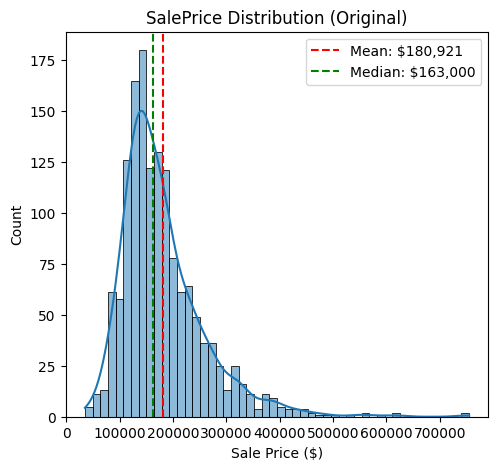

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['SalePrice'],bins=50,kde=True)
plt.axvline(df['SalePrice'].mean(),color='red',linestyle='--',label=f"Mean: ${df['SalePrice'].mean():,.0f}")
plt.axvline(df['SalePrice'].median(),color='green',linestyle='--',label=f"Median: ${df['SalePrice'].median():,.0f}")
plt.legend()
plt.title('SalePrice Distribution (Original)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Count')

SalePrice is heavily right-skewed, with most houses clustered below $250K and a much smaller number of expensive houses stretching the upper tail of the distribution.

The skewness value confirms this:
- skewness = 1.88

The mean price ($180K) is also noticeably higher than the median ($163K), which usually happens when expensive outliers pull the average upward.

This matters because regression models can become unstable when the target variable is extremely skewed.

A few expensive houses can disproportionately influence predictions and increase modelling error across the rest of the dataset.

To reduce that effect, I applied a log transformation to SalePrice before modelling.

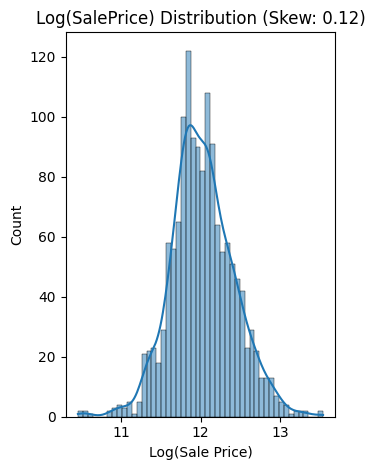

Original skewness: 1.88
After log transform: 0.12


In [16]:
plt.subplot(1,2,2)
sns.histplot(np.log(df['SalePrice']),bins=50,kde=True)
plt.title(f"Log(SalePrice) Distribution (Skew: {np.log(df['SalePrice']).skew():.2f})")
plt.xlabel('Log(Sale Price)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(f"Original skewness: {df['SalePrice'].skew():.2f}")
print(f"After log transform: {np.log(df['SalePrice']).skew():.2f}")

The log transformation reduced SalePrice skewness from 1.88 to 0.12, a 94% reduction in skewness.

After transformation:
- the distribution became much closer to normal
- extremely expensive houses became less dominant
- variance became more stable across the target range

This turned out to be one of the most important preprocessing steps in the entire project.

Without transformation, expensive houses would have disproportionately influenced the regression models, especially Linear Regression and Ridge.

The transformed distribution also looks much more suitable for models that assume roughly normal residual behavior later during evaluation.

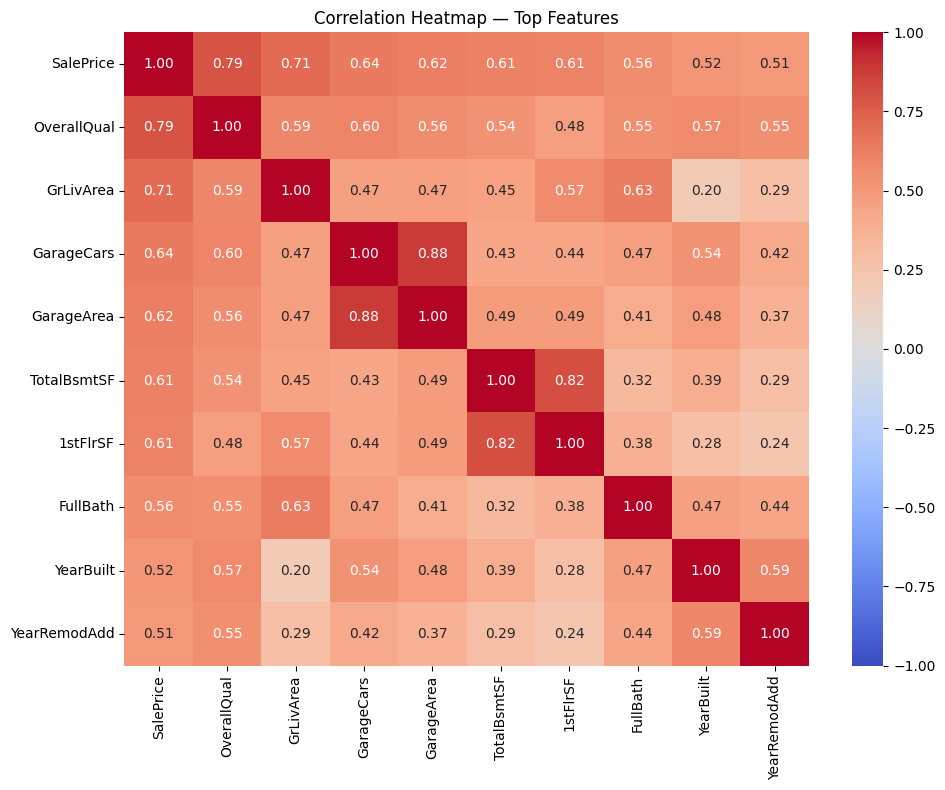

In [17]:
top_features = [
    'SalePrice',
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'YearBuilt',
    'YearRemodAdd'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap — Top Features')

plt.tight_layout()

plt.show()

The focused heatmap makes the strongest relationships much easier to interpret.

OverallQual remains the strongest single predictor of SalePrice at 0.79, followed by GrLivArea at 0.71.

One thing that became very clear here is that several top features are also strongly correlated with each other.

For example:
- GarageCars and GarageArea have a correlation close to 0.88
- multiple square-footage features move together
- newer houses also tend to have better quality ratings

That creates multicollinearity, where multiple variables contain overlapping information.

This is important because ordinary linear regression can become unstable when highly correlated variables compete against each other.

That was one of the reasons I later prioritized Ridge and Lasso regression, since regularization helps reduce coefficient instability caused by multicollinearity.

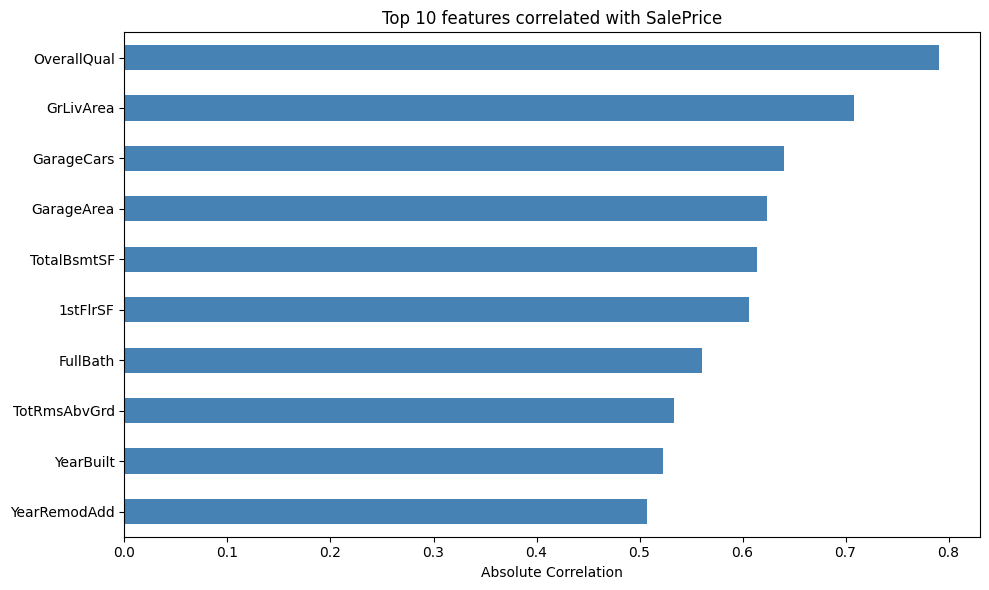

In [18]:
plt.figure(figsize=(10,6))
top_corr=numeric_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10)
top_corr.plot(kind='barh',color='steelblue')
plt.title('Top 10 features correlated with SalePrice')
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The strongest predictors follow a very consistent pattern:
- construction quality
- usable living space
- garage capacity
- basement size

OverallQual remains the strongest original feature, confirming that buyers place a very large premium on construction and material quality.

At the same time, multiple size-related variables also rank near the top:
- GrLivArea
- TotalBsmtSF
- GarageArea
- 1stFlrSF

What stood out was how often quality and size appeared together among the strongest predictors.

That pattern kept repeating throughout the EDA and later became one of the main reasons for creating the QualityScore interaction feature.

Instead of treating quality and size independently, the interaction feature captures the idea that:
a large high-quality house is worth disproportionately more than just large plus high-quality separately.

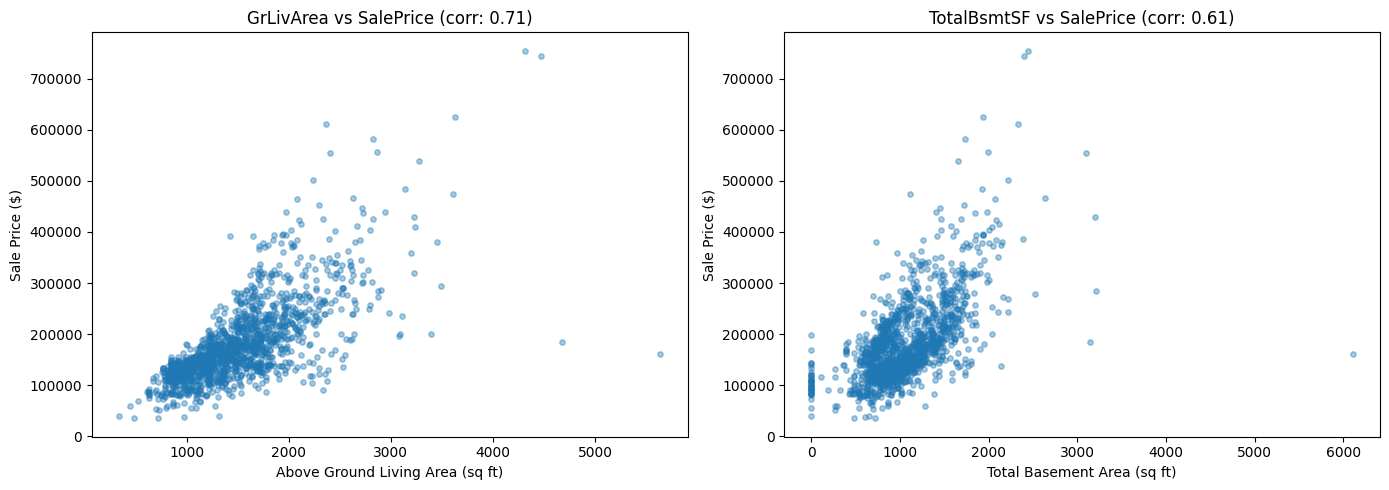

In [19]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(df['GrLivArea'], df ['SalePrice'],alpha=0.4,s=15)
axes[0].set_title('GrLivArea vs SalePrice (corr: 0.71)')
axes[0].set_xlabel('Above Ground Living Area (sq ft)')
axes[0].set_ylabel('Sale Price ($)')

axes[1].scatter(df['TotalBsmtSF'],df['SalePrice'],alpha=0.4,s=15)
axes[1].set_title('TotalBsmtSF vs SalePrice (corr: 0.61)')
axes[1].set_xlabel('Total Basement Area (sq ft)')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()

Both GrLivArea and TotalBsmtSF show strong positive relationships with SalePrice, confirming that larger houses generally sell for higher prices.

GrLivArea is especially important here, with a correlation of 0.71, one of the strongest relationships in the dataset.

What immediately stood out was a small cluster of houses above 4,000 sqft that sold for unusually low prices compared to the overall trend.

I expected houses that large to consistently appear near the top of the price range, so seeing oversized houses selling below $300K looked unusual enough to investigate further.

These points behave like outliers because they break the normal size-price relationship followed by most properties in the dataset.

That became important later because extreme outliers can disproportionately influence regression models, especially Linear Regression and Ridge.

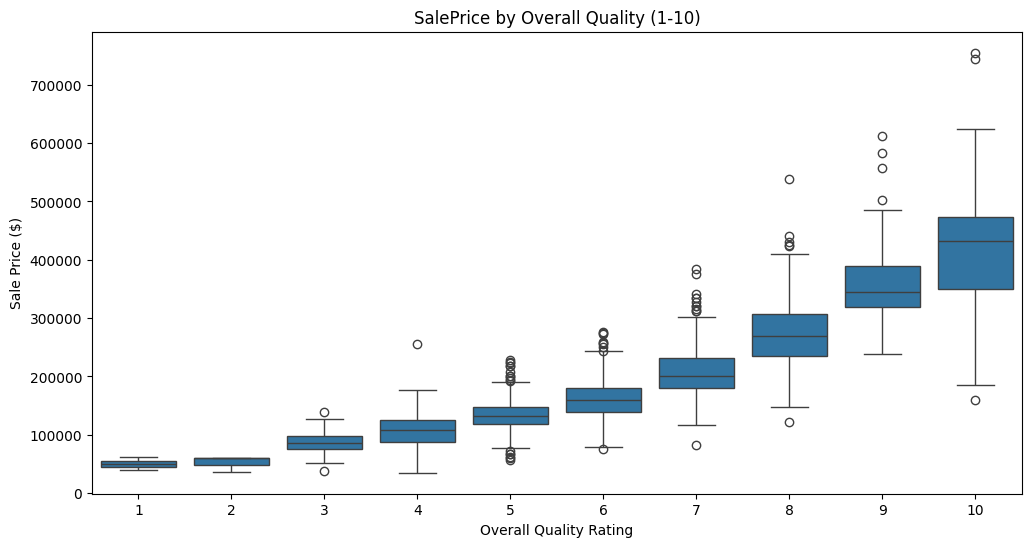

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(x='OverallQual',y='SalePrice',data=df)
plt.title('SalePrice by Overall Quality (1-10)')
plt.xlabel('Overall Quality Rating')
plt.ylabel('Sale Price ($)')
plt.show()

OverallQual has the strongest relationship with SalePrice among the original features in the dataset.

Quality 10 houses have a median sale price of $432,390, compared to only $50,150 for quality 1 houses, an 8.6× difference.

What surprised me was that the relationship is not linear.

I expected each quality level to increase price somewhat evenly, but the jump from quality 7 houses ($200,141 median) to quality 8 houses ($269,750 median) is much steeper than the earlier quality levels.

That means buyers appear to pay a disproportionately large premium for above-average quality rather than valuing each quality point equally.

Another pattern became obvious here:
the expensive houses are usually not just large, they are both large and high-quality at the same time.

That observation later led to the creation of:

QualityScore = OverallQual × GrLivArea

The interaction between quality and size turned out to be much more predictive than either feature individually.

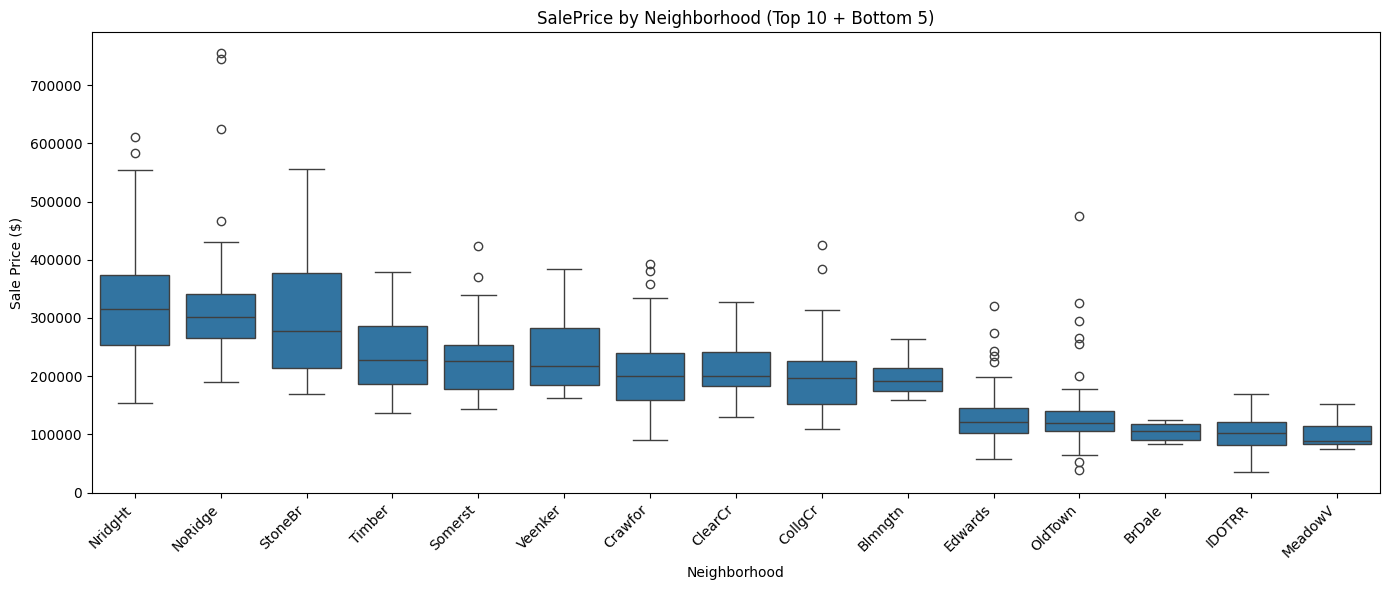

In [21]:
top_nb=df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
selected_nb=list(top_nb.head(10).index)+list(top_nb.tail().index)
df_nb=df[df['Neighborhood'].isin(selected_nb)]

plt.figure(figsize=(14,6))
order=top_nb.loc[top_nb.index.isin(selected_nb)].index
sns.boxplot(x='Neighborhood',y='SalePrice',data=df_nb,order=order)
plt.xticks(rotation=45,ha='right')
plt.title('SalePrice by Neighborhood (Top 10 + Bottom 5)')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

Neighborhood creates very large pricing differences across the dataset.

NridgHt has a median sale price of $315K, while MeadowV sits at only $88K, a 3.6× gap between the highest and lowest neighbourhood groups shown here.

So location clearly matters a lot.

But something interesting kept appearing during the analysis:
location alone still does not fully explain pricing.

Some houses inside premium neighbourhoods remain relatively affordable when their quality or living area is lower, while high-quality houses in average neighbourhoods can still sell at surprisingly high prices.

That pattern kept repeating throughout the EDA:
- quality matters
- size matters
- location matters

but the strongest-priced houses usually combine all three together rather than depending heavily on only one factor.

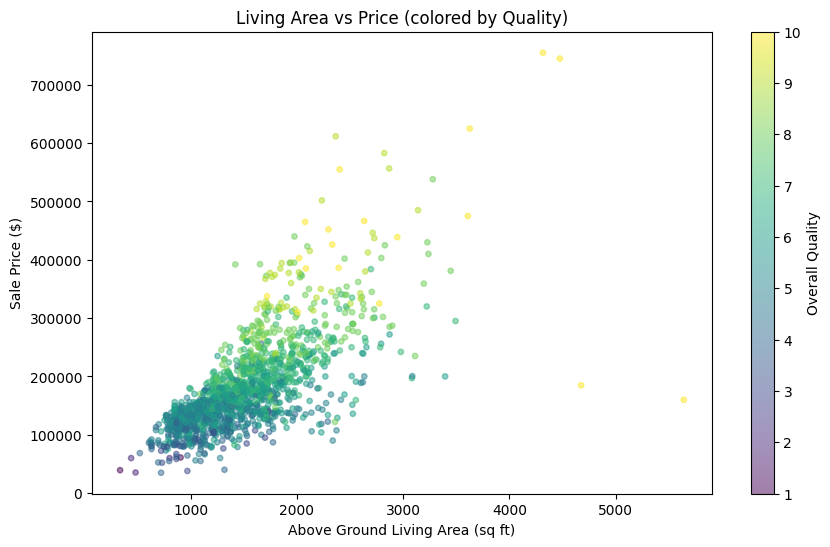

In [22]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['GrLivArea'], df['SalePrice'], c=df['OverallQual'], cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label='Overall Quality')
plt.title('Living Area vs Price (colored by Quality)')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()


Coloring the scatter plot by OverallQual made the interaction between size and quality much easier to see.

Large houses with lower quality ratings still often sell below smaller houses with very high quality ratings.

At the same time, the most expensive houses almost always combine:
- large living area
- high construction quality

rather than depending heavily on only one of them.

This was the point where the QualityScore feature started making sense conceptually.

Earlier charts already hinted that quality and size repeatedly appeared together among the strongest predictors, but this visualization made the interaction much more obvious.

That is why the QualityScore interaction feature later became one of the most important engineered variables in the project.

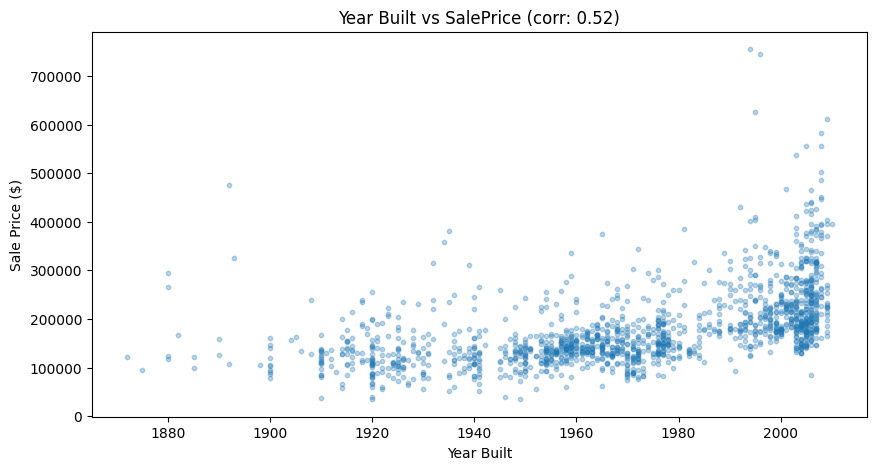

In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.3, s=10)
plt.title('Year Built vs SalePrice (corr: 0.52)')
plt.xlabel('Year Built')
plt.ylabel('Sale Price ($)')
plt.show()

Newer houses generally sell for higher prices, with YearBuilt showing a moderate positive correlation of 0.52 with SalePrice.

But the relationship here is noticeably weaker than features like:
- OverallQual
- GrLivArea
- Neighborhood

What stood out was that some older houses still sell at very high prices when their quality and condition remain strong.

That suggests buyers care less about raw age alone and more about how well the property has been maintained or renovated over time.

A well-maintained older system can often outperform a newer but poorly maintained one, and the same pattern appears here with housing quality and renovation.

That observation later influenced the creation of the HouseAge and RemodAge features during feature engineering.

# EDA Summary

Three findings shaped most of the later modelling decisions:

1. OverallQual was the strongest original predictor of SalePrice (correlation: 0.79), showing that construction quality influences pricing more consistently than any other single feature.

2. SalePrice was heavily right-skewed (skewness: 1.88), making log transformation necessary before linear modelling.

3. Large houses alone were not automatically expensive. The highest-priced houses consistently combined:
   - large living area
   - high construction quality
   - strong neighbourhood value

The EDA also revealed:
- strong multicollinearity between several numerical features
- a small number of extreme outliers
- major price differences across neighbourhoods
- repeated interaction patterns between quality and size

These findings directly influenced the next modelling decisions.

Because of the EDA results:
- SalePrice was log-transformed
- extreme outliers were removed
- interaction features like QualityScore were engineered
- regularized regression models were prioritized to handle multicollinearity more effectively

The exploratory analysis helped turn raw housing data into modelling decisions instead of relying on assumptions alone.

# 3. Missing Value Treatment

The dataset contains several columns with missing values, but the earlier exploration showed that not all missing values mean the same thing.

After looking through the feature descriptions and missing-value patterns, the missing data naturally fell into three groups:

1. the feature does not exist in the house
2. the feature logically should be zero
3. genuinely missing or incomplete information

For example, a missing PoolQC value usually means the house does not have a pool, not that the pool quality is unknown.

The same pattern appears in several other features:
- missing garage-related columns often mean no garage exists
- missing basement features can indicate no basement
- some numerical missing values logically represent zero area or zero count

Because of this, using one imputation strategy across the entire dataset would distort the meaning of the data.

Instead, different imputation methods were chosen depending on what the missing value actually represented in the real world.

In [24]:
df_clean = df.copy()


In [25]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in none_cols:
    df_clean[col] = df_clean[col].fillna('None')

For several categorical columns, missing values actually represent the absence of that feature rather than unknown information.

Examples:
- missing PoolQC → no pool
- missing Alley → no alley access
- missing FireplaceQu → no fireplace

Replacing these missing values with "None" preserves useful information because the absence of a feature can itself affect house prices.

A house without a fireplace or garage is meaningfully different from a house where that information is simply unavailable.

This ended up being one of the most important ideas in the preprocessing stage:
missing values were not automatically treated as bad data.
In many cases, the missing value itself carried useful information.

In [26]:
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
for col in zero_cols:
    df_clean[col] = df_clean[col].fillna(0)

print(f"After 'no feature' fills: {df_clean.isnull().sum().sum()} missing cells remaining")

After 'no feature' fills: 1140 missing cells remaining


Some numerical columns had missing values because the feature itself was absent.

For example:
- missing GarageArea usually means the house has no garage
- missing basement square footage usually means no basement exists

In these cases, filling with 0 is logically consistent because the property genuinely has zero area, zero rooms, or zero count for that feature.

This also helps the model distinguish between:
- a feature not existing
- a feature having an actual measured value

Using averages here would have created unrealistic values and incorrectly implied that the feature existed.

In [27]:
df_clean['MasVnrType'] = df_clean['MasVnrType'].fillna('None')
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)

print(f"After MasVnr fills: {df_clean.isnull().sum().sum()} missing cells remaining")

After MasVnr fills: 260 missing cells remaining


In [28]:
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

print(f"After LotFrontage fill: {df_clean.isnull().sum().sum()} missing cells remaining")

After LotFrontage fill: 1 missing cells remaining


LotFrontage required a different strategy.

LotFrontage represents the linear feet of property connected to the street, so filling missing values with 0 would not make practical sense.

Instead, missing values were filled using the median LotFrontage within each neighborhood.

I considered using the overall dataset median, but neighborhood-wise imputation felt much more realistic because houses in the same neighborhood usually follow similar:
- lot layouts
- street widths
- property dimensions

This approach preserves local housing patterns much better than a single global fill value.

In [29]:
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

print(f"After Electrical fill: {df_clean.isnull().sum().sum()} missing cells remaining")

After Electrical fill: 0 missing cells remaining


In [30]:
assert df_clean.isnull().sum().sum() == 0, "ERROR: Still have missing values!"
print(" ZERO missing values! All clean.")

 ZERO missing values! All clean.


After applying the different imputation strategies, the training dataset no longer contained any missing values.

Before moving into feature engineering and modelling, I verified that:
- no NaN values remained
- feature types stayed consistent
- the imputations still preserved realistic housing information

This step mattered because most machine learning models cannot handle missing values directly, and poor imputation decisions can unintentionally distort relationships inside the data.

The biggest lesson from this stage was that missing values are not always missing data.

In many cases, they represented meaningful real-world information about the house itself, and preserving that meaning turned out to be more important than simply removing NaNs.

# 4. Outlier Removal

During exploratory data analysis, I identified two houses with extremely large living areas but unusually low sale prices compared to the overall market trend.

These houses did not follow the normal relationship between:
- living area
- construction quality
- sale price

Most houses above 4,000 sqft sold at very high prices, but these two properties sold below $300K despite their unusually large size.

Cases like these may represent:
- distressed sales
- unusual private transactions
- incomplete records
- or abnormal market conditions

Because regression models are highly sensitive to extreme observations, these points can disproportionately pull the regression line and distort the learned relationship between GrLivArea and SalePrice.

Since only two highly abnormal observations were involved, I removed them before training the final models.

In [31]:
print(f"\nBefore outlier removal: {df_clean.shape[0]} houses")
df_clean = df_clean[~((df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000))]
print(f"After outlier removal: {df_clean.shape[0]} houses")
print("Removed 2 houses: huge area but suspiciously low price (likely errors)")


Before outlier removal: 1460 houses
After outlier removal: 1458 houses
Removed 2 houses: huge area but suspiciously low price (likely errors)


Only two rows were removed from the dataset, so the impact on dataset size was minimal.

I initially considered keeping them because removing data should always be done carefully, especially with smaller datasets.

But these houses behaved very differently from the rest of the market.

Large houses almost always appeared near the top of the pricing range throughout the EDA, so seeing 4,000+ sqft houses selling unusually low looked more like abnormal observations than genuine market behavior.

Removing them helped the regression models learn a more realistic size-price relationship while preserving almost the entire dataset.

In [32]:
df_clean['MSSubClass'] = df_clean['MSSubClass'].astype(str)

print(f"\nDataset ready for feature engineering")
print(f"  Rows: {df_clean.shape[0]} (was {df.shape[0]})")
print(f"  Columns: {df_clean.shape[1]}")
print(f"  Missing values: {df_clean.isnull().sum().sum()}")


Dataset ready for feature engineering
  Rows: 1458 (was 1460)
  Columns: 81
  Missing values: 0


# 5. Feature Engineering

The exploratory analysis showed that house prices are driven more by combinations of features than by isolated variables alone.

Several patterns appeared repeatedly during EDA:
- larger houses generally sell for more
- higher-quality houses command major price premiums
- remodeled houses often outperform older unrenovated homes
- quality and size repeatedly appeared together among the strongest predictors

Because of this, I created additional features designed to better represent how buyers actually evaluate houses in practice.

Instead of relying only on the original dataset columns, the engineered features combine:
- insights discovered during EDA
- relationships between important variables
- practical housing intuition

Some of these engineered features later became stronger predictors than many of the original variables.

In [33]:
df_clean['TotalSF'] = df_clean['TotalBsmtSF'] + df_clean['1stFlrSF'] + df_clean['2ndFlrSF']


In [34]:
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']


In [35]:
df_clean['RemodAge'] = df_clean['YrSold'] - df_clean['YearRemodAdd']


In [36]:
df_clean['TotalBath'] = df_clean['FullBath'] + df_clean['BsmtFullBath'] + 0.5 * df_clean['HalfBath'] + 0.5 * df_clean['BsmtHalfBath']


In [37]:
df_clean['HasPool'] = np.where(df_clean['PoolArea'] > 0, 1, 0)


In [38]:
df_clean['HasGarage'] = np.where(df_clean['GarageArea'] > 0, 1, 0)


In [39]:
df_clean['QualityScore'] = df_clean['OverallQual'] * df_clean['GrLivArea']


In [40]:
df_clean['LogSalePrice'] = np.log(df_clean['SalePrice'])



Several new features were created to help the models capture housing relationships more realistically and improve prediction accuracy.

---

### TotalSF

This feature combines:
- basement area
- first floor area
- second floor area

into a single total square footage feature.

During EDA, multiple size-related variables appeared among the strongest predictors of SalePrice. Combining them into one variable gives a cleaner representation of total usable living space.

---

### HouseAge

This feature measures how old the house was when sold.

Created using:

**YrSold - YearBuilt**

The EDA showed that newer houses generally sell for higher prices, but some older well-maintained houses still performed strongly.

HouseAge helps capture long-term aging effects more directly than raw construction year alone.

---

### RemodAge

This feature measures how many years had passed since the house was remodeled.

Created using:

**YrSold - YearRemodAdd**

I created this because buyers often care more about how modern or updated a house feels rather than only when it was originally built.

---

### TotalBath

This feature combines all bathroom information into a single value.

Half bathrooms were weighted as 0.5 because they provide partial functionality compared to full bathrooms.

This creates a more realistic representation of bathroom utility inside the house.

---

### HasPool

This binary feature identifies whether the house has a pool.

- 1 → house has a pool
- 0 → no pool

Pools are rare in the dataset, so simply having one may matter more than the exact pool size itself.

---

### HasGarage

This binary feature identifies whether the house has a garage.

- 1 → garage exists
- 0 → no garage

The presence of a garage alone can create a noticeable pricing difference, especially in suburban neighborhoods.

---

### QualityScore

This interaction feature combines:
- OverallQual
- GrLivArea

using multiplication:

**OverallQual × GrLivArea**

This became the strongest engineered feature in the entire project.

During EDA, I kept noticing that expensive houses were usually not just large or high-quality, they were both at the same time.

QualityScore started almost as an experiment. I expected it to help somewhat, but I did not expect it to become the single strongest feature at 47.24% importance in the Gradient Boosting model.

What makes the interaction useful is that:
- a large low-quality house is not necessarily expensive
- a small high-quality house can still sell at a premium

The interaction captures that relationship much better than size or quality alone.

---

### LogSalePrice

The target variable SalePrice was log-transformed to reduce skewness and improve regression performance.

Earlier EDA showed that SalePrice skewness dropped from 1.88 to 0.12 after transformation, making the distribution much closer to normal and more suitable for regression models.

In [41]:
print("Feature engineering completed")
print(f"  Columns: {df_clean.shape[1]} (was 81, added 8 new features)")
print(f"  SalePrice skew: {df_clean['SalePrice'].skew():.2f} → LogSalePrice skew: {df_clean['LogSalePrice'].skew():.2f}")
print(f"LogSalePrice skewness: "f"{df_clean['LogSalePrice'].skew():.2f}"
)

Feature engineering completed
  Columns: 89 (was 81, added 8 new features)
  SalePrice skew: 1.88 → LogSalePrice skew: 0.12
LogSalePrice skewness: 0.12


# 6. Model Preparation

After feature engineering, the dataset still needed several preprocessing steps before machine learning models could be trained properly.

The preparation process included:
- separating features and target variables
- encoding categorical columns
- splitting the dataset into training and testing sets
- scaling numerical variables where necessary

The goal was to build a preprocessing workflow that could support both:
- linear regression models
- tree-based machine learning models

This setup also makes model comparison more reliable later because every algorithm is trained on the same cleaned and engineered dataset.

In [42]:

y = df_clean['LogSalePrice']
X = df_clean.drop(columns=['SalePrice', 'LogSalePrice', 'Id'])
print(f"Features: {X.shape[1]} columns, Target: {y.shape[0]} values")


Features: 86 columns, Target: 1458 values


In [43]:
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Before encoding: {X.shape[1]} → After: {X_encoded.shape[1]} columns")


Before encoding: 86 → After: 278 columns


The dataset contains many categorical variables such as:
- Neighborhood
- HouseStyle
- GarageType
- exterior materials

Machine learning models cannot work directly with text categories, so these variables were converted into numerical format using one-hot encoding.

I used:

drop_first=True

In [44]:


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} houses, Test: {X_test.shape[0]} houses")


Train: 1166 houses, Test: 292 houses


In [45]:



num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"\n Phase 7 Complete! X_train: {X_train.shape}, X_test: {X_test.shape}")


 Phase 7 Complete! X_train: (1166, 278), X_test: (292, 278)


Feature scaling was used to standardize numerical variables so they operate on similar ranges during training.

This is especially important for:
- Linear Regression
- Ridge Regression
- Lasso Regression

because these models are sensitive to feature magnitudes.

Without scaling, variables with very large numeric ranges can dominate the optimization process and distort coefficient behavior.

Tree-based models like Random Forest and Gradient Boosting are generally much less sensitive to scaling, but the scaled dataset still helped maintain a consistent preprocessing workflow across all models.

To avoid data leakage, the scaler was fitted only on the training data and then applied to both training and testing sets.

# 7. Model Building & Comparison

After preprocessing and feature engineering, the next step was to compare multiple regression models on the prepared dataset.

The goal was not simply to choose the most complex algorithm.

I wanted a model that:
- performs well on unseen data
- generalizes reliably
- avoids severe overfitting
- balances predictive accuracy with interpretability

The models were evaluated using:
- cross-validation RMSE
- training RMSE
- testing RMSE
- R² score

Comparing both training and testing performance was important because strong training accuracy alone does not guarantee good real-world predictions.

In [46]:

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}




In [47]:
results = {}
for name, model in models.items():

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)


    model.fit(X_train, y_train)


    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)


    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    results[name] = {'cv': cv_rmse.mean(), 'train': train_rmse, 'test': test_rmse, 'r2': test_r2}

    print(f"{name:25s} CV: {cv_rmse.mean():.4f} | Train: {train_rmse:.4f} | Test: {test_rmse:.4f} | R²: {test_r2:.4f}")




Linear Regression         CV: 0.1336 | Train: 0.0847 | Test: 0.1439 | R²: 0.8772
Ridge                     CV: 0.1189 | Train: 0.0874 | Test: 0.1285 | R²: 0.9020
Lasso                     CV: 0.1153 | Train: 0.1030 | Test: 0.1228 | R²: 0.9105
Random Forest             CV: 0.1371 | Train: 0.0513 | Test: 0.1432 | R²: 0.8784
Gradient Boosting         CV: 0.1241 | Train: 0.0766 | Test: 0.1230 | R²: 0.9103


The model comparison produced a few results that I did not fully expect at the beginning of the project.

Lasso Regression and Gradient Boosting produced the strongest overall test performance:
- Lasso test RMSE: 0.1228
- Gradient Boosting test RMSE: 0.1230

The difference between them was only 0.0002, so their predictive performance was essentially tied.

What became more important was how differently the models behaved internally.

Random Forest achieved extremely low training error:
- train RMSE: 0.0513

but much worse test performance:
- test RMSE: 0.1432

That gap strongly suggests overfitting.

The model learned the training data extremely well but generalized less effectively to unseen houses.

Lasso behaved much more consistently:
- CV RMSE: 0.1153
- train RMSE: 0.1030
- test RMSE: 0.1228

The smaller train-test gap suggests more stable generalization.

What I found interesting was that the simplest regularized model ended up competing directly with Gradient Boosting, despite Gradient Boosting being a much more flexible algorithm.

Lasso also brought several practical advantages:
- lower overfitting risk
- automatic feature selection
- easier interpretation
- reduced model complexity

After one-hot encoding expanded the feature space significantly, Lasso automatically shrank many coefficients to zero and kept only the most useful predictors.

Because of this balance between:
- predictive accuracy
- stability
- interpretability
- feature selection

Lasso Regression was selected as the final model for the project.

In [48]:
gb = models['Gradient Boosting']
importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(f"\nTop 10 features (Gradient Boosting):")
for i, (feat, imp) in enumerate(importances.head(10).items(), 1):
    print(f"  {i:2d}. {feat:30s} {imp:.4f}")


lasso = models['Lasso']
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
print(f"\nLasso kept {(lasso_coefs != 0).sum()} features, dropped {(lasso_coefs == 0).sum()}")


Top 10 features (Gradient Boosting):
   1. QualityScore                   0.4724
   2. TotalSF                        0.1641
   3. OverallQual                    0.0924
   4. TotalBath                      0.0332
   5. HouseAge                       0.0272
   6. GarageCars                     0.0245
   7. GarageArea                     0.0182
   8. CentralAir_Y                   0.0165
   9. BsmtFinSF1                     0.0162
  10. YearRemodAdd                   0.0136

Lasso kept 82 features, dropped 196


The feature importance results confirmed several patterns discovered earlier during EDA.

QualityScore became the single most important feature at 47.24% importance, far higher than any individual original variable.

What surprised me was how dominant this interaction became.

I originally created QualityScore mainly as an experiment combining:
- house quality
- living area

because those two variables kept appearing together throughout the exploratory analysis.

I expected the interaction to help somewhat, but I did not expect it to outperform every original feature so heavily.

The next strongest features also followed the same general pattern:
- TotalSF
- OverallQual
- TotalBath
- GarageCars

Most of the top predictors are still connected to:
- usable space
- construction quality
- or overall functionality of the house

This reinforces one of the biggest findings from the project:

buyers are not simply paying for larger houses or better-quality houses separately, they are paying a premium for houses that combine both size and quality together.

The Lasso model also reduced the feature space significantly:
- kept 82 features
- dropped 196 features

That automatic feature selection helped simplify the model while preserving strong predictive performance.

What I found interesting was that the simpler regularized model remained competitive with much more flexible ensemble models, even after aggressively shrinking the feature space.

# 8. Final Model Evaluation

After selecting Lasso Regression as the final model, I evaluated its performance using multiple regression metrics.

The evaluation focused on:
- overall prediction accuracy
- average prediction error
- percentage-based error
- real-world interpretability of predictions

Since the model was trained on LogSalePrice, the predictions were converted back to the original dollar scale using np.exp() so the results could be interpreted more realistically.

In [49]:
log_pred = lasso.predict(X_test)
dollar_pred = np.exp(log_pred)
dollar_actual = np.exp(y_test)




In [50]:
rmse_log = np.sqrt(mean_squared_error(y_test, log_pred))
r2 = r2_score(y_test, log_pred)
rmse_dollar = np.sqrt(mean_squared_error(dollar_actual, dollar_pred))
mae_dollar = mean_absolute_error(dollar_actual, dollar_pred)
mape = np.mean(np.abs((dollar_actual - dollar_pred) / dollar_actual)) * 100

print(f"Log-space:  RMSE={rmse_log:.4f}, R²={r2:.4f}")
print(f"Dollars:    RMSE=${rmse_dollar:,.0f}, MAE=${mae_dollar:,.0f}")
print(f"MAPE:       {mape:.1f}% average error")




Log-space:  RMSE=0.1228, R²=0.9105
Dollars:    RMSE=$20,005, MAE=$14,368
MAPE:       8.8% average error


The final model achieved an R² score of 0.9105, meaning it explains just over 91% of the variation in house prices across the dataset.

The prediction errors were:
- RMSE: $20,005
- MAE: $14,368
- MAPE: 8.8%

For context, the median house price in the dataset is about $163K, so an RMSE of $20K corresponds to roughly 12% of a typical house price.

The MAE being lower than the RMSE also suggests that most prediction errors are fairly moderate, while a smaller number of larger mistakes, mostly from expensive houses, pull the RMSE upward.

The MAPE result was especially useful because it makes the errors easier to interpret in practical terms.

An average percentage error of 8.8% means the model is usually fairly close to the actual selling price despite the large variability in housing values.

Overall, the model captured pricing patterns surprisingly well considering the dataset contains a wide range of house types, neighborhoods, and pricing behaviors.

In [51]:
residuals = y_test - log_pred
print(f"Mean residual: {residuals.mean():.4f} (should be near 0)")




Mean residual: -0.0053 (should be near 0)


The mean residual remained very close to zero:
- mean residual = -0.0053

That is a good sign because it suggests the model is not systematically overpricing or underpricing houses overall.

The slightly negative value indicates a very small tendency toward overprediction on average, but the magnitude is small enough that the bias is practically negligible.

In [52]:
abs_errors = np.abs(dollar_actual - dollar_pred)
print(f"Within $10K: {(abs_errors < 10000).sum()} houses ({(abs_errors < 10000).mean()*100:.0f}%)")
print(f"Within $25K: {(abs_errors < 25000).sum()} houses ({(abs_errors < 25000).mean()*100:.0f}%)")
print(f"Within $50K: {(abs_errors < 50000).sum()} houses ({(abs_errors < 50000).mean()*100:.0f}%)")







Within $10K: 142 houses (49%)
Within $25K: 232 houses (79%)
Within $50K: 283 houses (97%)


The prediction-band analysis made the model performance much easier to interpret in practical terms.

The model predicted:
- 49% of houses within $10K of the actual sale price
- 79% within $25K
- 97% within $50K

What stood out was how consistently the model performed across the majority of houses in the dataset.

Most prediction errors remained relatively moderate, especially considering the housing prices range from below $50K to above $750K.

The model performed best on mid-range houses, which makes sense because those properties appear most frequently in the training data and follow more stable pricing patterns.

The larger prediction errors mostly occurred for:
- luxury homes
- unusually expensive properties
- houses with rare feature combinations

Those houses are naturally harder to predict because fewer comparable examples exist in the dataset.

Overall, the prediction ranges suggest the model generalizes well for typical residential properties while struggling more with rare high-end cases.

# 9. Residual Analysis

After evaluating prediction accuracy, I also wanted to check how well the final regression model captured the underlying pricing patterns.

Residual analysis helps verify whether:
- prediction errors remain unbiased
- systematic patterns still exist in the errors
- variance remains reasonably stable across predictions

A strong regression model should produce residuals that appear randomly distributed around zero rather than forming visible patterns.

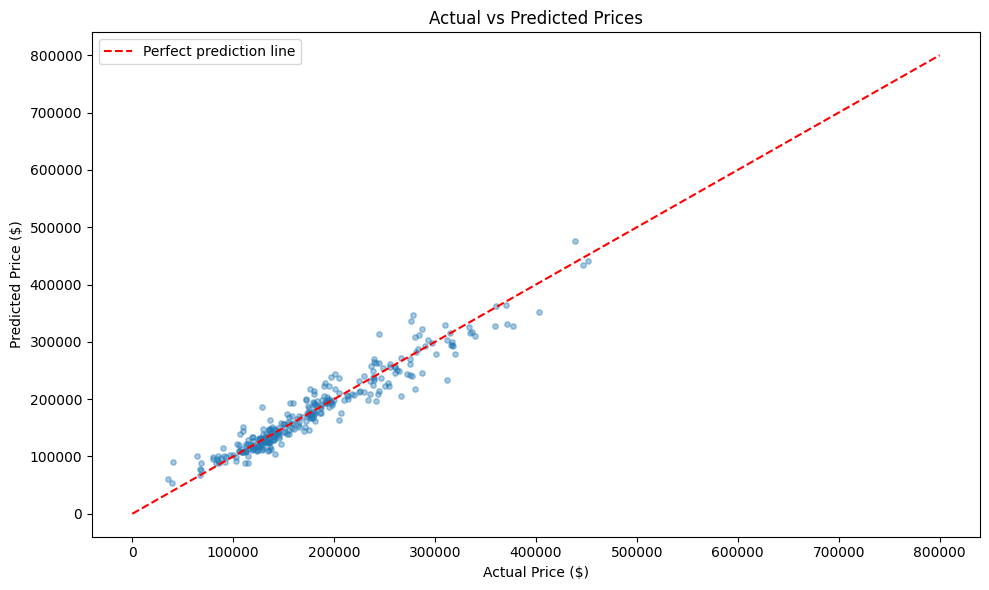

In [53]:
plt.figure(figsize=(10, 6))
plt.scatter(dollar_actual, dollar_pred, alpha=0.4, s=15)
plt.plot([0, 800000], [0, 800000], 'r--', label='Perfect prediction line')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

Most predictions cluster reasonably close to the diagonal perfect-prediction line, showing that the model captures the overall pricing relationship well across most houses.

What stood out was that mid-range houses were predicted much more consistently than very expensive properties.

The spread of prediction errors becomes larger for high-end houses, which is expected because luxury homes appear less frequently in the dataset and often contain rare combinations of features.

Those properties are naturally harder to model using standard regression techniques because there are fewer comparable training examples available.

Even with that increased spread at the upper end of the market, the overall prediction pattern still follows the diagonal relationship closely, which suggests the model generalizes well across the majority of the dataset.

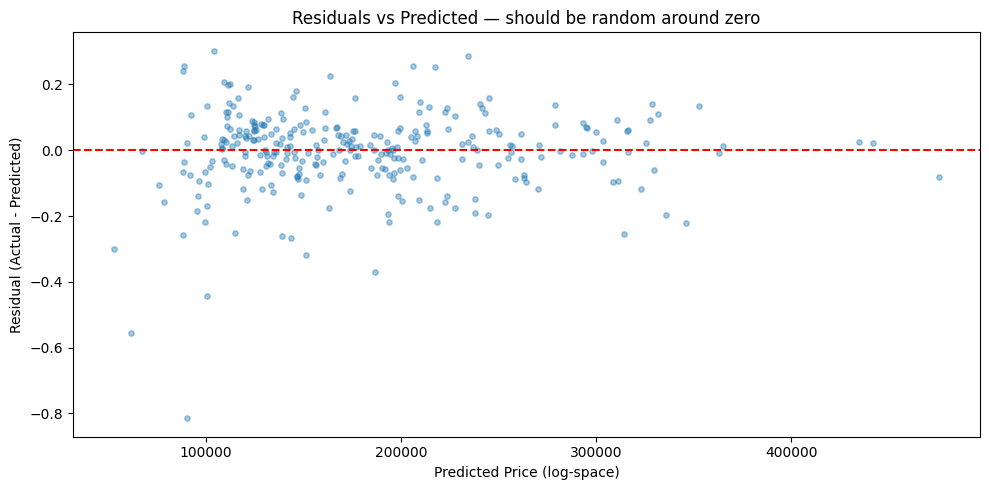

In [54]:
plt.figure(figsize=(10, 5))
plt.scatter(dollar_pred, residuals, alpha=0.4, s=15)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted — should be random around zero')
plt.xlabel('Predicted Price (log-space)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

The residuals appear randomly scattered around zero without any strong visible structure, which suggests the model captured the main pricing relationships reasonably well.

I specifically looked for funnel-shaped behavior that would indicate heteroscedasticity, but the residual spread remained relatively stable across most prediction ranges.

The earlier log transformation of SalePrice appears to have helped significantly here by reducing variance instability among higher-priced houses.

Although a few larger residuals still appear for luxury properties, the model does not show strong systematic bias toward:
- overpredicting prices
- underpredicting prices

Overall, the residual behavior suggests the regression assumptions hold fairly well after preprocessing and transformation.

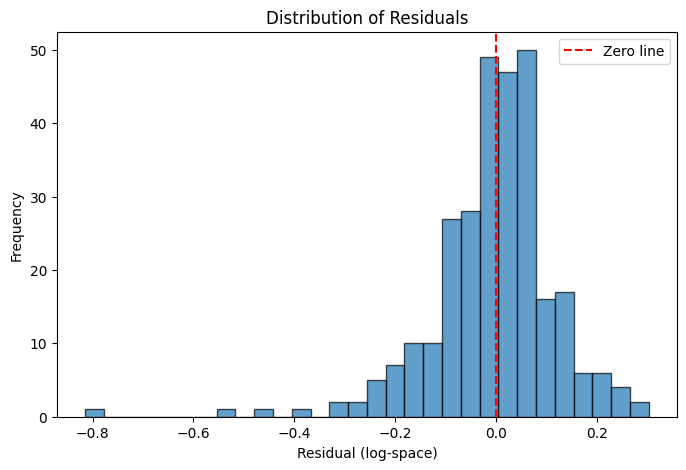

Skewness: -1.55
Kurtosis: 7.66


In [55]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)

plt.axvline(x=0, color='red', linestyle='--', label='Zero line')

plt.title('Distribution of Residuals')
plt.xlabel('Residual (log-space)')
plt.ylabel('Frequency')

plt.legend()
plt.show()

print(f"Skewness: {residuals.skew():.2f}")
print(f"Kurtosis: {residuals.kurtosis():.2f}")

The residual distribution remains centered close to zero, which is consistent with the earlier residual plots.

However, the distribution is not perfectly normal:
- skewness = -1.55
- kurtosis = 7.66

The negative skewness indicates that larger negative residuals occur more often than equally large positive residuals.

In practical terms, this means the model occasionally overpredicts house prices by larger amounts than it underpredicts them.

The high kurtosis value also shows that the residual distribution contains heavier tails than a perfect normal distribution, meaning a small number of larger prediction errors still exist.

Most of these larger residuals appear to come from expensive or unusual houses, which is consistent with the earlier scatter plots.

Even with these remaining tail effects, the majority of residuals remain concentrated near zero, and the model still performs reliably across most typical residential properties in the dataset.

# 10. Kaggle Submission

After selecting Lasso Regression as the final model, I retrained it using the entire cleaned training dataset before generating predictions for the Kaggle test.csv file.

This allows the model to learn from all available training examples instead of reserving part of the data for validation.

The final prediction pipeline included:
- missing value treatment
- feature engineering
- one-hot encoding
- feature alignment
- scaling
- prediction generation

Using the full dataset before final prediction helps maximize the information available to the model in a deployment-style setting.

In [56]:

y_all = df_clean['LogSalePrice']
X_all = df_clean.drop(columns=['SalePrice', 'LogSalePrice', 'Id'])
X_all_encoded = pd.get_dummies(X_all, drop_first=True)
train_columns = X_all_encoded.columns.tolist()

scaler_final = StandardScaler()
num_cols = X_all_encoded.select_dtypes(include=['int64', 'float64']).columns
X_all_scaled = X_all_encoded.copy()
X_all_scaled[num_cols] = scaler_final.fit_transform(X_all_encoded[num_cols])

final_model = Lasso(alpha=0.001)
final_model.fit(X_all_scaled, y_all)
print(f"Final model trained on ALL {X_all_scaled.shape[0]} houses")



Final model trained on ALL 1458 houses


In [57]:

test = pd.read_csv('test.csv')
test_ids = test['Id']
test_clean = test.copy()


for col in none_cols:
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].fillna('None')
for col in zero_cols:
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].fillna(0)
test_clean['MasVnrType'] = test_clean['MasVnrType'].fillna('None')
test_clean['MasVnrArea'] = test_clean['MasVnrArea'].fillna(0)
test_clean['LotFrontage'] = test_clean.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
test_clean['MSSubClass'] = test_clean['MSSubClass'].astype(str)




In [58]:
for col in test_clean.select_dtypes(include=['float64','int64']).columns:
    test_clean[col] = test_clean[col].fillna(test_clean[col].median())
for col in test_clean.select_dtypes(include=['object']).columns:
    test_clean[col] = test_clean[col].fillna(test_clean[col].mode()[0])


test_clean['TotalSF'] = test_clean['TotalBsmtSF'] + test_clean['1stFlrSF'] + test_clean['2ndFlrSF']
test_clean['HouseAge'] = test_clean['YrSold'] - test_clean['YearBuilt']
test_clean['RemodAge'] = test_clean['YrSold'] - test_clean['YearRemodAdd']
test_clean['TotalBath'] = test_clean['FullBath'] + test_clean['BsmtFullBath'] + 0.5*test_clean['HalfBath'] + 0.5*test_clean['BsmtHalfBath']
test_clean['HasPool'] = np.where(test_clean['PoolArea'] > 0, 1, 0)
test_clean['HasGarage'] = np.where(test_clean['GarageArea'] > 0, 1, 0)
test_clean['QualityScore'] = test_clean['OverallQual'] * test_clean['GrLivArea']




In [59]:
test_features = test_clean.drop(columns=['Id'])
test_encoded = pd.get_dummies(test_features, drop_first=True)


for col in set(train_columns) - set(test_encoded.columns):
    test_encoded[col] = 0
test_encoded = test_encoded[train_columns]


test_encoded[num_cols] = scaler_final.transform(test_encoded[num_cols])




In [60]:
log_predictions = final_model.predict(test_encoded)
dollar_predictions = np.exp(log_predictions)   # Convert log → dollars

print(f"Predictions: {len(dollar_predictions)}")
print(f"Range: ${dollar_predictions.min():,.0f} to ${dollar_predictions.max():,.0f}")




Predictions: 1459
Range: $51,518 to $1,854,833


In [61]:
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': dollar_predictions})
submission.to_csv('submission.csv', index=False)
print(f"\n submission.csv created! {submission.shape[0]} predictions")
print(submission.head())


 submission.csv created! 1459 predictions
     Id      SalePrice
0  1461  111960.417998
1  1462  152355.954692
2  1463  177921.193682
3  1464  201266.134308
4  1465  190551.777901


## Final Kaggle Submission

The final submission file was generated in the format required by Kaggle:
- Id
- SalePrice

Because the model was trained on LogSalePrice, all predictions were converted back to the original dollar scale using:


np.exp()



# 11. Conclusion

This project built a complete end-to-end machine learning pipeline for predicting house prices using the Ames Housing dataset.

The workflow included:
- data cleaning
- missing value treatment
- exploratory data analysis
- outlier removal
- feature engineering
- preprocessing
- model comparison
- residual analysis
- and Kaggle-style prediction generation

Several regression models were tested, including:
- Linear Regression
- Ridge
- Lasso
- Random Forest
- Gradient Boosting

Although Gradient Boosting and Lasso produced almost identical predictive performance, Lasso Regression was ultimately selected because it generalized more consistently while remaining simpler and easier to interpret.

The final model achieved:
- R² = 0.9105
- RMSE = $20,005
- MAE = $14,368
- MAPE = 8.8%
- 79% of predictions within $25K of the actual sale price

One of the biggest findings from the project was that house prices were influenced more strongly by the interaction between quality and size than I originally expected.

The engineered feature:

**QualityScore = OverallQual × GrLivArea**

became the single strongest predictor at 47.24% feature importance.

At the beginning of the project, I expected neighborhood and location to dominate pricing behavior much more heavily.

Instead, construction quality repeatedly emerged as the strongest driver of house prices across almost every stage of the analysis.

What I found most interesting was that the expensive houses were usually not just:
- large
- well-located
- or high-quality individually

they consistently combined all of those characteristics together.

Overall, this project reinforced how important feature engineering and careful preprocessing can be for structured tabular machine learning problems.

In many cases, the biggest performance improvements did not come from using more complex algorithms, but from understanding the relationships inside the data more deeply.

# Key Findings

- OverallQual was the strongest original predictor of SalePrice with a correlation of 0.79.
- GrLivArea also showed a very strong relationship with SalePrice (correlation: 0.71).
- SalePrice skewness dropped from 1.88 to 0.12 after log transformation.
- Neighborhood created major pricing differences, with NridgHt median prices about 3.6× higher than MeadowV.
- Large houses alone were not automatically expensive, the highest-priced houses consistently combined size and quality together.
- QualityScore became the strongest engineered feature at 47.24% importance in the Gradient Boosting model.
- Random Forest achieved very low training error but showed clear signs of overfitting.
- Lasso Regression generalized more consistently across unseen data while also reducing the feature space significantly.
- 79% of final predictions were within $25K of the actual sale price.

# Improvements & Future Work

If I continued developing this project further, the next thing I would explore would probably be more advanced ensemble methods such as:
- XGBoost
- LightGBM
- stacking/blending approaches

I would also spend more time on:
- hyperparameter tuning
- repeated cross-validation
- SHAP-based explainability
- additional neighborhood-level feature engineering

One thing that became obvious during the project is that the dataset still lacks several important real-world economic factors.

Housing prices are influenced by much more than the physical house itself.

If external datasets were available, I would be especially interested in adding:
- mortgage interest rates
- school quality ratings
- crime statistics
- local income levels
- regional economic indicators

I think those factors could improve prediction performance significantly, especially for higher-priced houses where the current model still struggles more.

Another area I would explore is whether separate models for:
- luxury homes
- mid-range homes
- lower-priced homes

might outperform a single global regression model.

The residual analysis suggested that expensive houses behave differently enough that they may benefit from a more specialized modelling approach.